# First Draft 
This is the first Draft using **RandomForest** model , **PSO** optimization , Keeping **Epochs : 5**

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from mealpy.swarm_based import PSO
from mealpy.utils.problem import FloatVar
import warnings
warnings.filterwarnings('ignore')

# ----------------------------
# Load your Sentiment dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])

    df = pd.concat([amazon, imdb, yelp], axis=0)

    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

# ----------------------------
# Objective function for PSO
# ----------------------------
def objective_function(solution):
    global X_train, y_train

    n_estimators = int(solution[0])
    max_depth = int(solution[1]) if solution[1] > 0 else None
    min_samples_split = int(solution[2])
    min_samples_leaf = int(solution[3])
    max_features = solution[4]

    try:
        rf = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        )
        scores = cross_val_score(rf, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Negative because optimizer minimizes
    except Exception:
        fitness = 1.0  # Penalty if invalid

    return fitness

# ----------------------------
# Run PSO optimization
# ----------------------------
def optimize_random_forest():
    global X_train, X_test, y_train, y_test
    X_train, X_test, y_train, y_test = load_data()

    print("Starting Random Forest optimization with Mealpy PSO...")
    print(f"Training set size: {X_train.shape}")
    print(f"Test set size: {X_test.shape}")
    print("-" * 50)

    # Problem bounds for hyperparameters
    problem = {
        "bounds": [
            FloatVar(lb=10, ub=200, name="n_estimators"),
            FloatVar(lb=1, ub=20, name="max_depth"),
            FloatVar(lb=2, ub=20, name="min_samples_split"),
            FloatVar(lb=1, ub=10, name="min_samples_leaf"),
            FloatVar(lb=0.1, ub=1.0, name="max_features")
        ],
        "minmax": "min",
        "obj_func": objective_function
    }

    optimizer = PSO.OriginalPSO(epoch=5, pop_size=10)
    best_agent = optimizer.solve(problem)  # Returns Agent object
    best_position = best_agent.solution          # Correct attribute for params
    best_fitness = best_agent.target.fitness     # Extract numeric float

    print("\nOptimization Results:")
    print("-" * 50)
    print(f"Best fitness (negative accuracy): {best_fitness:.6f}")
    print(f"Best accuracy: {-best_fitness:.6f}")

    best_params = {
        'n_estimators': int(best_position[0]),
        'max_depth': int(best_position[1]) if best_position[1] > 0 else None,
        'min_samples_split': int(best_position[2]),
        'min_samples_leaf': int(best_position[3]),
        'max_features': best_position[4],
        'random_state': 42
    }

    print("\nBest Hyperparameters:")
    for param, value in best_params.items():
        print(f"  {param}: {value}")

    return best_params

# ----------------------------
# Evaluate optimized model
# ----------------------------
def evaluate_model(best_params):
    global X_train, X_test, y_train, y_test

    print("\n" + "="*50)
    print("FINAL MODEL EVALUATION")
    print("="*50)

    best_rf = RandomForestClassifier(**best_params)
    best_rf.fit(X_train, y_train)

    y_pred = best_rf.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    print(f"Test Accuracy: {test_accuracy:.6f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    print("\nComparison with default Random Forest:")
    default_rf = RandomForestClassifier(random_state=42)
    default_rf.fit(X_train, y_train)
    default_pred = default_rf.predict(X_test)
    default_accuracy = accuracy_score(y_test, default_pred)

    print(f"Default RF Accuracy: {default_accuracy:.6f}")
    print(f"Optimized RF Accuracy: {test_accuracy:.6f}")
    print(f"Improvement: {test_accuracy - default_accuracy:.6f}")

if __name__ == "__main__":
    best_params = optimize_random_forest()
    evaluate_model(best_params)
    print("\n" + "="*50)
    print("OPTIMIZATION COMPLETE!")
    print("="*50)

2025/09/10 06:29:44 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Starting Random Forest optimization with Mealpy PSO...
Training set size: (2198, 1000)
Test set size: (550, 1000)
--------------------------------------------------


2025/09/10 06:30:07 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.6942785717303196, Global best: -0.6942785717303196, Runtime: 13.59577 seconds
2025/09/10 06:30:17 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.6942785717303196, Global best: -0.6942785717303196, Runtime: 10.02248 seconds
2025/09/10 06:30:27 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.6942785717303196, Global best: -0.6942785717303196, Runtime: 10.56789 seconds
2025/09/10 06:30:37 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7006463444635789, Global best: -0.7006463444635789, Runtime: 9.20082 seconds
2025/09/10 06:30:47 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7006463444635789, Global best: -0.7006463444635789, Runtime: 10.56082 seconds



Optimization Results:
--------------------------------------------------
Best fitness (negative accuracy): -0.700646
Best accuracy: 0.700646

Best Hyperparameters:
  n_estimators: 86
  max_depth: 18
  min_samples_split: 14
  min_samples_leaf: 5
  max_features: 0.9706760067948874
  random_state: 42

FINAL MODEL EVALUATION
Test Accuracy: 0.727273

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.94      0.77       273
    Positive       0.89      0.52      0.66       277

    accuracy                           0.73       550
   macro avg       0.78      0.73      0.72       550
weighted avg       0.78      0.73      0.72       550


Comparison with default Random Forest:
Default RF Accuracy: 0.818182
Optimized RF Accuracy: 0.727273
Improvement: -0.090909

OPTIMIZATION COMPLETE!


In [12]:
def evaluate_model(best_params):
    global X_train, X_test, y_train, y_test

    print("\n" + "="*50)
    print("FINAL MODEL EVALUATION")
    print("="*50)

    best_rf = RandomForestClassifier(**best_params)
    best_rf.fit(X_train, y_train)

    y_pred = best_rf.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)

    print(f"Test Accuracy: {test_accuracy:.6f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    print("\nComparison with default Random Forest:")
    default_rf = RandomForestClassifier(random_state=42)
    default_rf.fit(X_train, y_train)
    default_pred = default_rf.predict(X_test)
    default_accuracy = accuracy_score(y_test, default_pred)

    print(f"Default RF Accuracy: {default_accuracy:.6f}")
    print(f"Optimized RF Accuracy: {test_accuracy:.6f}")
    print(f"Improvement: {test_accuracy - default_accuracy:.6f}")

    # Call visualization here
    visualize_metrics(y_test, y_pred, test_accuracy, default_accuracy)


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def visualize_metrics(y_test, y_pred, test_accuracy, default_accuracy):
    # Classification report as dict
    report = classification_report(y_test, y_pred, target_names=['Negative', 'Positive'], output_dict=True)

    # Extract precision, recall, f1 for each class
    classes = ['Negative', 'Positive']
    metrics = ['precision', 'recall', 'f1-score']
    values = [[report[c][m] for m in metrics] for c in classes]

    # --- Bar chart: Precision, Recall, F1 per class ---
    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar(x - width/2, values[0], width, label="Negative")
    ax.bar(x + width/2, values[1], width, label="Positive")

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_ylabel("Score")
    ax.set_title("Classification Metrics per Class")
    ax.legend()
    plt.ylim(0, 1)
    plt.show()

    # --- Accuracy comparison ---
    fig, ax = plt.subplots()
    acc_values = [default_accuracy, test_accuracy]
    ax.bar(["Default RF", "Optimized RF"], acc_values, color=["red", "green"])
    ax.set_ylabel("Accuracy")
    ax.set_title("Model Accuracy Comparison")
    plt.ylim(0, 1)
    plt.show()

    # --- Confusion Matrix Heatmap ---
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()


2025/09/10 06:30:55 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Starting Random Forest optimization with Mealpy PSO...
Training set size: (2198, 1000)
Test set size: (550, 1000)
--------------------------------------------------


2025/09/10 06:31:20 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7079292127320665, Global best: -0.7079292127320665, Runtime: 14.91111 seconds
2025/09/10 06:31:32 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7083852073843798, Global best: -0.7083852073843798, Runtime: 12.25778 seconds
2025/09/10 06:31:48 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7083852073843798, Global best: -0.7083852073843798, Runtime: 16.47609 seconds
2025/09/10 06:32:03 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7092909842278035, Global best: -0.7092909842278035, Runtime: 15.03098 seconds
2025/09/10 06:32:16 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7106583469386235, Global best: -0.7106583469386235, Runtime: 12.67907 seconds



Optimization Results:
--------------------------------------------------
Best fitness (negative accuracy): -0.710658
Best accuracy: 0.710658

Best Hyperparameters:
  n_estimators: 154
  max_depth: 18
  min_samples_split: 16
  min_samples_leaf: 4
  max_features: 0.12325625756673086
  random_state: 42

FINAL MODEL EVALUATION
Test Accuracy: 0.725455

Classification Report:
              precision    recall  f1-score   support

    Negative       0.66      0.94      0.77       273
    Positive       0.90      0.51      0.65       277

    accuracy                           0.73       550
   macro avg       0.78      0.73      0.71       550
weighted avg       0.78      0.73      0.71       550


Comparison with default Random Forest:
Default RF Accuracy: 0.818182
Optimized RF Accuracy: 0.725455
Improvement: -0.092727


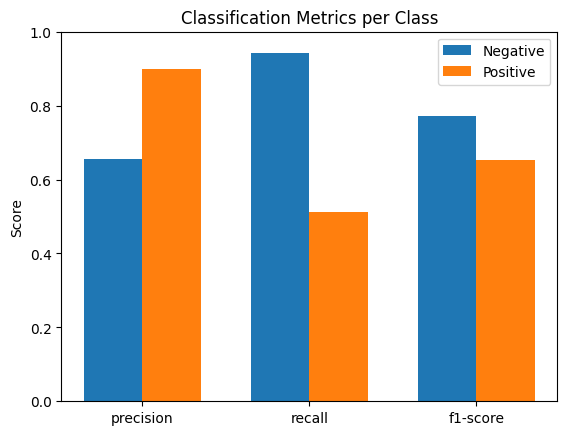

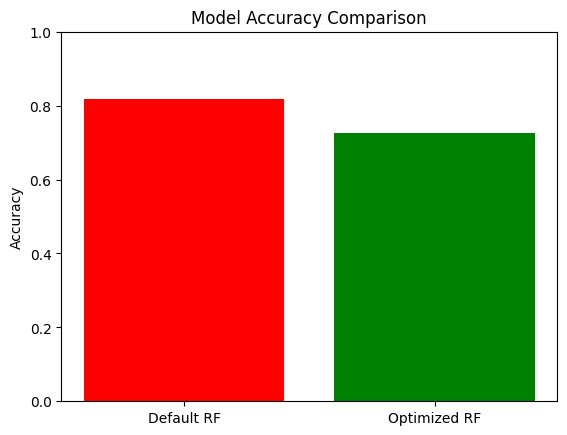

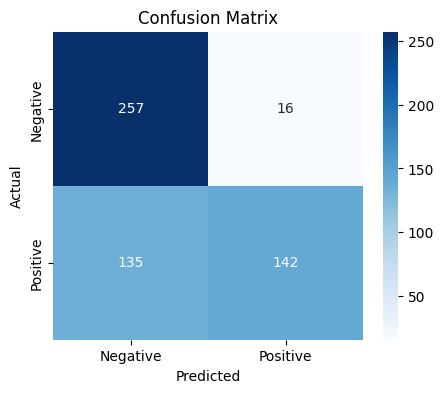

In [14]:
best_params = optimize_random_forest()
evaluate_model(best_params)
